# WAC framelet-boundary NULLs: where `reproject`'s dashes come from, and how to fill them

`reproject` renders show short horizontal dashes along crater-shadow edges and bright specks inside
shadows. This notebook traces them to a fixed set of NULL pixels `lrowaccal` leaves on the first
line of every 14-line WAC VIS framelet, then compares two ways to fill those pixels in the crop,
before `cam2map`:

- **Row interpolation**: linear interpolation along the line across each 1-3 px gap.
- **Previous-framelet donor**: consecutive framelets overlap by a couple of lines on the ground, so
  each NULL pixel's ground was also seen by the previous framelet. Fit where (per column) and copy
  that pixel over.

It then builds a replacement for `cam2map` that avoids the NULLs, and a seam misplacement of
`cam2map`'s own, by construction. That replacement, `wac_resample`, is what the pipeline now uses to
map-project the crop (`wac_resample.map_project_crop`, `TrntestConfig.crop_map_projection`).

The example is `trntest1` entry 175, `M1314448520CE`. The notebook builds its own one-entry
dataset from `trntest1`'s manifest row, so nothing under `trntest1` itself is touched.

In [1]:
import dataclasses
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio.warp
from pyproj import Transformer
from scipy.ndimage import binary_erosion, binary_fill_holes, gaussian_filter, uniform_filter

import trntest
from trntest import dem_ortho, isis_campt, isis_wac, plotting, render
from trntest.geo_utils import geographic_crs
from trntest.wac_format import VIS_BLOCK_HEIGHT
from trntest.wac_framelet_fill import (
    ISIS_NULL,
    cam2map_source_pixels,
    camera_model_overlap,
    fill_from_previous_framelet,
    fill_row_interp,
    fit_framelet_overlap,
    framelet_boundary_nulls,
    read_all_bands,
    write_filled_cube,
)
from trntest.wac_resample import MapGrid, fill_small_holes, resample_crop, write_geotiff

PRODUCT_ID = "M1314448520CE"
TRNTEST1_MANIFEST = Path("/workspace/output_global/trntest1/manifest.csv")
# Checked at the end: a mid-latitude entry from another month, a northern one, and the opposite yaw
# state (`M1327210646CE`, from the frozen demo manifest).
OTHER_ENTRIES = {
    "M1309273576CE": Path("/workspace/output_global/trntest2/manifest.csv"),
    "M1314403930CE": TRNTEST1_MANIFEST,
    "M1327210646CE": Path("dataset_manifest.csv"),
}
ZOOM = 120  # zoom window size, px
INTERIOR_PHASES = (3, 9)  # framelet lines well away from either overlap
MIN_TILE_COVERAGE = 0.95

config = trntest.load_config()
manifests = {PRODUCT_ID: TRNTEST1_MANIFEST, **OTHER_ENTRIES}
images = pd.concat(
    [trntest.read_manifest(path).query("product_id == @product_id") for product_id, path in manifests.items()],
    ignore_index=True,
)
dataset = trntest.TrnTestDataSet.create(config.output_dir / "wac_framelet_null_fill", images, config)
entry = dataset[PRODUCT_ID]
work_dir = config.scratch_dir / "wac_framelet_null_fill"
work_dir.mkdir(parents=True, exist_ok=True)

camera = entry.camera  # also furnishes the SPICE kernels camera_model_overlap needs
crop = entry.crop_result
dem = entry.dem_ortho_result
baseline_render = entry.images_by_type["reproject"].generate()
print(crop.cub_path)
print(baseline_render)

/workspace/cache/wac_crop/M1314448520CE_crop.cub
/workspace/output/wac_framelet_null_fill/reproject/M1314448520CE_reproject.tif


In [2]:
def stretch(image: np.ndarray) -> tuple[float, float]:
    return tuple(np.nanpercentile(image, [1, 99.5]))


def busiest_window(diff: np.ndarray, size: int = ZOOM) -> tuple[slice, slice]:
    """The `size`-px square window with the most |diff| in it."""
    energy = uniform_filter(np.nan_to_num(np.abs(diff)), size)
    row, col = np.unravel_index(np.argmax(energy), energy.shape)
    row0 = int(np.clip(row - size // 2, 0, diff.shape[0] - size))
    col0 = int(np.clip(col - size // 2, 0, diff.shape[1] - size))
    return slice(row0, row0 + size), slice(col0, col0 + size)


def show_zooms(panels: dict[str, np.ndarray], window, diff_of: tuple[str, str] | None = None):
    """Side-by-side zooms sharing one stretch, plus an optional difference panel."""
    n = len(panels) + (diff_of is not None)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5.2))
    vmin, vmax = stretch(next(iter(panels.values()))[window])
    for ax, (title, image) in zip(axes, panels.items(), strict=False):
        ax.imshow(image[window], cmap="gray", vmin=vmin, vmax=vmax, interpolation="none")
        ax.set_title(title)
    if diff_of is not None:
        a, b = diff_of
        diff = (panels[a] - panels[b])[window]
        lim = (vmax - vmin) / 4
        im = axes[-1].imshow(diff, cmap="RdBu", vmin=-lim, vmax=lim, interpolation="none")
        axes[-1].set_title(f"{a} - {b}")
        fig.colorbar(im, ax=axes[-1], fraction=0.046)
    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
    fig.tight_layout()
    return fig

## The NULL pattern in the crop

The crop is a slice of the framestitched, calibrated cube: 14 lines per framelet, line 0 of the
crop being a framelet's first line. Counting NULLs by line position within the framelet (its
"phase") shows the pattern is confined to phase 0 of band 1, the band `cam2map_for_crop` keeps.
Every phase also carries the 3 always-dead edge columns, so phase 0 of band 1 has 53 columns of its
own.

In [3]:
bands = dict(enumerate(read_all_bands(crop.cub_path), start=1))
counts = pd.DataFrame(
    {
        f"band {b}": [
            int(np.isnan(band[phase::VIS_BLOCK_HEIGHT]).sum() / (band.shape[0] // VIS_BLOCK_HEIGHT))
            for phase in range(VIS_BLOCK_HEIGHT)
        ]
        for b, band in bands.items()
    }
).rename_axis("phase")
counts.T

phase,0,1,2,3,4,5,6,7,8,9,10,11,12,13
band 1,56,3,3,3,3,3,3,3,3,3,3,3,3,3
band 2,4,3,3,3,3,3,3,3,3,3,3,3,3,3
band 3,5,3,3,3,3,3,3,3,3,3,3,3,3,3
band 4,4,3,3,3,3,3,3,3,3,3,3,3,3,3
band 5,4,3,3,3,3,3,3,3,3,3,3,3,3,3


crop (896, 704): 3392 boundary NULLs, 53 columns per framelet
same columns in every framelet: True


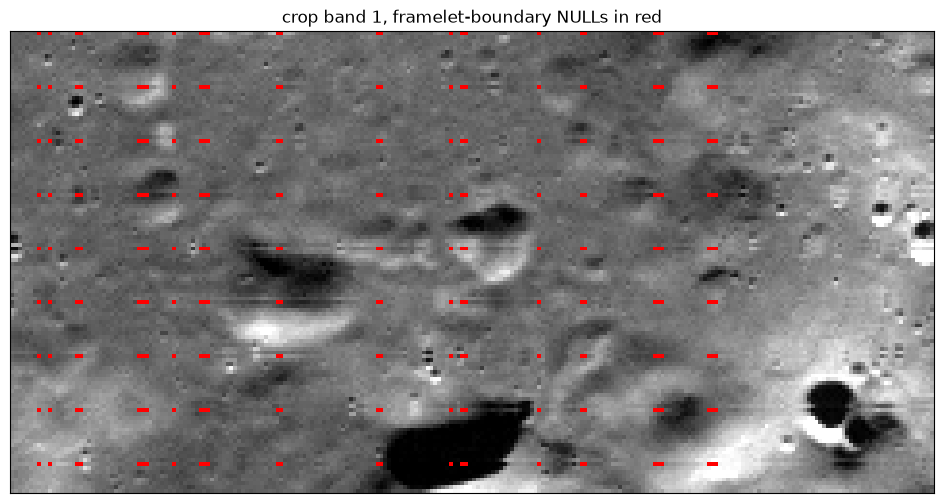

In [4]:
band = bands[1]
boundary_nulls = framelet_boundary_nulls(band)
null_cols = np.flatnonzero(boundary_nulls[0])
same_every_framelet = all(
    np.array_equal(np.flatnonzero(boundary_nulls[row]), null_cols) for row in range(0, band.shape[0], VIS_BLOCK_HEIGHT)
)
print(f"crop {band.shape}: {boundary_nulls.sum()} boundary NULLs, {len(null_cols)} columns per framelet")
print(f"same columns in every framelet: {same_every_framelet}")

rows, cols = slice(280, 400), slice(200, 440)
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(
    band[rows, cols],
    cmap="gray",
    vmin=np.nanpercentile(band, 1),
    vmax=np.nanpercentile(band, 99.5),
    interpolation="none",
)
ax.imshow(np.where(boundary_nulls[rows, cols], 1.0, np.nan), cmap="autumn", interpolation="none")
ax.set_title("crop band 1, framelet-boundary NULLs in red")
_ = ax.set_xticks([]), ax.set_yticks([])

## Why the NULLs reach the output

Consecutive framelets overlap on the ground, so `cam2map` has two candidate source pixels for
the ground at each framelet seam. Which one wins is visible by running `cam2map` with the same
arguments `run_cam2map_for_crop` uses, but nearest-neighbor, on a copy of the crop whose pixels hold
their own line number.

Phase 0 (the NULL line) wins its full share of output pixels. It's the *previous* framelet's
overlapping last lines (phases 10-12) that get overwritten. So the NULLs land in the map. The
current texture has almost no NULL pixels left, so `cam2map` substitutes nearby values for them
(exactly how is unconfirmed). Those substitutions are the dashes and specks.

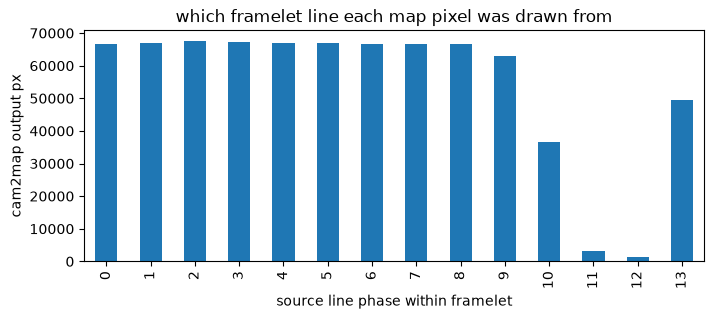

In [5]:
source_lines, source_samples = cam2map_source_pixels(crop.cub_path, dem, work_dir / "source_pixels.tif")
source_phase = np.where(np.isfinite(source_lines), np.nan_to_num(source_lines).astype(int) % VIS_BLOCK_HEIGHT, -1)
phase_share = pd.Series([(source_phase == p).sum() for p in range(VIS_BLOCK_HEIGHT)], name="output px")
fig, ax = plt.subplots(figsize=(8, 3))
phase_share.plot.bar(ax=ax)
ax.set_xlabel("source line phase within framelet")
ax.set_ylabel("cam2map output px")
_ = ax.set_title("which framelet line each map pixel was drawn from")

## How much the framelets overlap

`fit_framelet_overlap` finds, per 64-column block, the (fractional) line of the previous framelet
and the cross-track shift that best reproduce each framelet's first line. The result is smooth and
symmetric about the center column, the shape expected from the camera's radial distortion: about
11.9 lines (2.1 lines of overlap) at the center, about 10.5 at the edges.

per-block fit RMSE (I/F): [0.00082 0.00072 0.00078 0.00074 0.00069 0.00068 0.00072 0.0009  0.00092
 0.00085 0.00091]


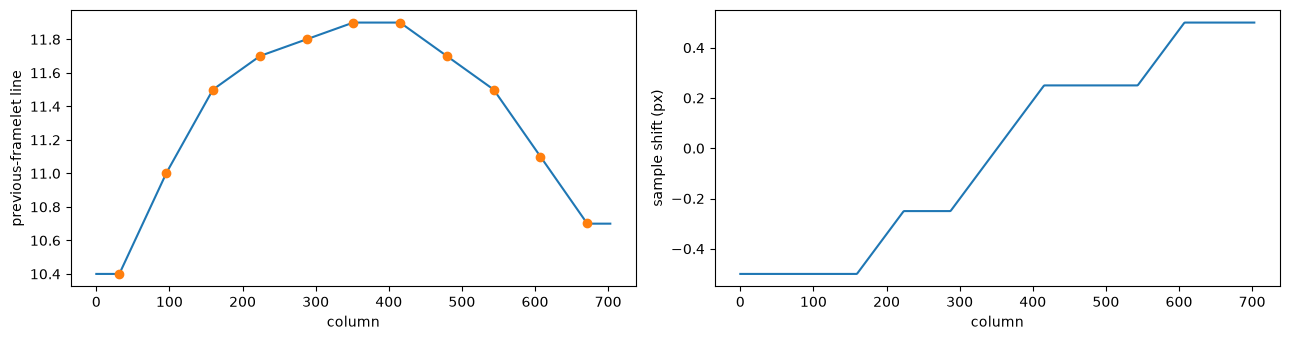

In [6]:
overlap = fit_framelet_overlap(band)
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
axes[0].plot(overlap.line_offset)
axes[0].plot(
    overlap.block_centers, np.interp(overlap.block_centers, np.arange(band.shape[1]), overlap.line_offset), "o"
)
axes[0].set_ylabel("previous-framelet line")
axes[1].plot(overlap.sample_shift)
axes[1].set_ylabel("sample shift (px)")
for ax in axes:
    ax.set_xlabel("column")
fig.tight_layout()
print("per-block fit RMSE (I/F):", np.round(overlap.block_rmse, 5))

## Checking the overlap against the camera model

The fit above uses only pixels. The camera model gives an independent prediction:
`camera_model_overlap` takes first-line pixels of every 6th framelet to ground with `campt`, then
projects those ground points into the previous framelet with `pose_alignment.wac_camera_model`
(the hand-rolled WAC projector, validated against `campt`). Projecting each point back into its own
framelet must return the pixel it started from, which checks the time and pixel conventions.

If the two estimates agree, the framelets are consistently registered and any remaining seam
artifact comes from how `cam2map` resamples them. If they disagree, the camera model is off at the
seams.

round-trip into own framelet, max |error|: line 6.4e-05, sample 9.3e-05 px
      line: camera - image fit  shift: camera - image fit  \
mean                     0.032                      0.058   
50%                      0.023                      0.062   
max                      0.163                      0.147   

      line: spread across framelets  
mean                          0.064  
50%                           0.053  
max                           0.144  


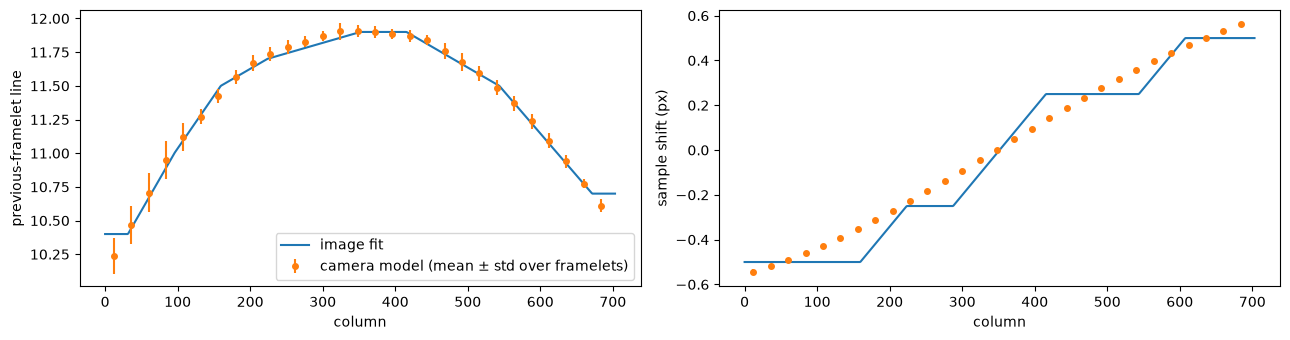

In [7]:
model_overlap, model_points = camera_model_overlap(crop.cub_path)
print(
    "round-trip into own framelet, max |error|: "
    f"line {model_points['self_line_error'].abs().max():.1e}, "
    f"sample {model_points['self_sample_error'].abs().max():.1e} px"
)

per_column = model_points.groupby("column")[["line_offset", "sample_shift"]].agg(["mean", "std"])
image_at = per_column.index.to_numpy()
comparison = pd.DataFrame(
    {
        "line: camera - image fit": per_column[("line_offset", "mean")] - overlap.line_offset[image_at],
        "shift: camera - image fit": per_column[("sample_shift", "mean")] - overlap.sample_shift[image_at],
        "line: spread across framelets": per_column[("line_offset", "std")],
    }
)
print(comparison.abs().describe().loc[["mean", "50%", "max"]].round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
for ax, key, label in (
    (axes[0], "line_offset", "previous-framelet line"),
    (axes[1], "sample_shift", "sample shift (px)"),
):
    ax.plot(getattr(overlap, key), label="image fit")
    ax.errorbar(
        image_at,
        per_column[(key, "mean")],
        yerr=per_column[(key, "std")],
        fmt="o",
        ms=4,
        label="camera model (mean ± std over framelets)",
    )
    ax.set_xlabel("column")
    ax.set_ylabel(label)
axes[0].legend()
fig.tight_layout()

## Held-out comparison of the two fills

The fills can't be checked against the NULL pixels themselves, so the test uses valid pixels
instead: shift the 53-column NULL pattern sideways by a few offsets, hide those phase-0 pixels,
refit the overlap without them, fill them each way, and compare against their true values. The
integer "two lines back" donor is included to show that the fractional offset matters, and the
camera-model overlap to show whether the image fit is needed at all.

In [8]:
held_out = np.zeros_like(boundary_nulls)
for shift in (7, 13, 21, 33):
    shifted = null_cols + shift
    shifted = shifted[shifted < band.shape[1] - 2]
    held_out[::VIS_BLOCK_HEIGHT, shifted] = True
held_out &= np.isfinite(band)
held_out[:VIS_BLOCK_HEIGHT] = False  # first framelet has no previous framelet to draw from
truth = band[held_out]
hidden = np.where(held_out, np.nan, band)
held_out_overlap = fit_framelet_overlap(hidden)

rows_h, cols_h = np.nonzero(held_out)
estimates = {
    "row interpolation": fill_row_interp(hidden, held_out)[held_out],
    "previous framelet, 2 lines back": hidden[rows_h - 2, cols_h],
    "previous framelet, fitted offset": fill_from_previous_framelet(hidden, held_out, held_out_overlap)[held_out],
    "previous framelet, camera-model offset": fill_from_previous_framelet(hidden, held_out, model_overlap)[held_out],
}
errors = pd.DataFrame(
    {
        name: {
            "RMSE (I/F)": np.sqrt(np.nanmean((est - truth) ** 2)),
            "RMSE / pixel std": np.sqrt(np.nanmean((est - truth) ** 2)) / np.std(truth),
            "median |err| / value": np.nanmedian(np.abs(est - truth) / np.abs(truth)),
        }
        for name, est in estimates.items()
    }
).T
print(f"{held_out.sum()} held-out pixels")
errors.style.format("{:.4f}")

10143 held-out pixels


,RMSE (I/F),RMSE / pixel std,median |err| / value
row interpolation,0.0015,0.2878,0.0453
"previous framelet, 2 lines back",0.0016,0.3011,0.0413
"previous framelet, fitted offset",0.0007,0.1395,0.0275
"previous framelet, camera-model offset",0.0007,0.1382,0.0275


## Effect on the map-projected texture

Both fills, written into copies of the crop and run through `run_cam2map_for_crop` unchanged.
The zoom is the window where the fill changes the texture most.

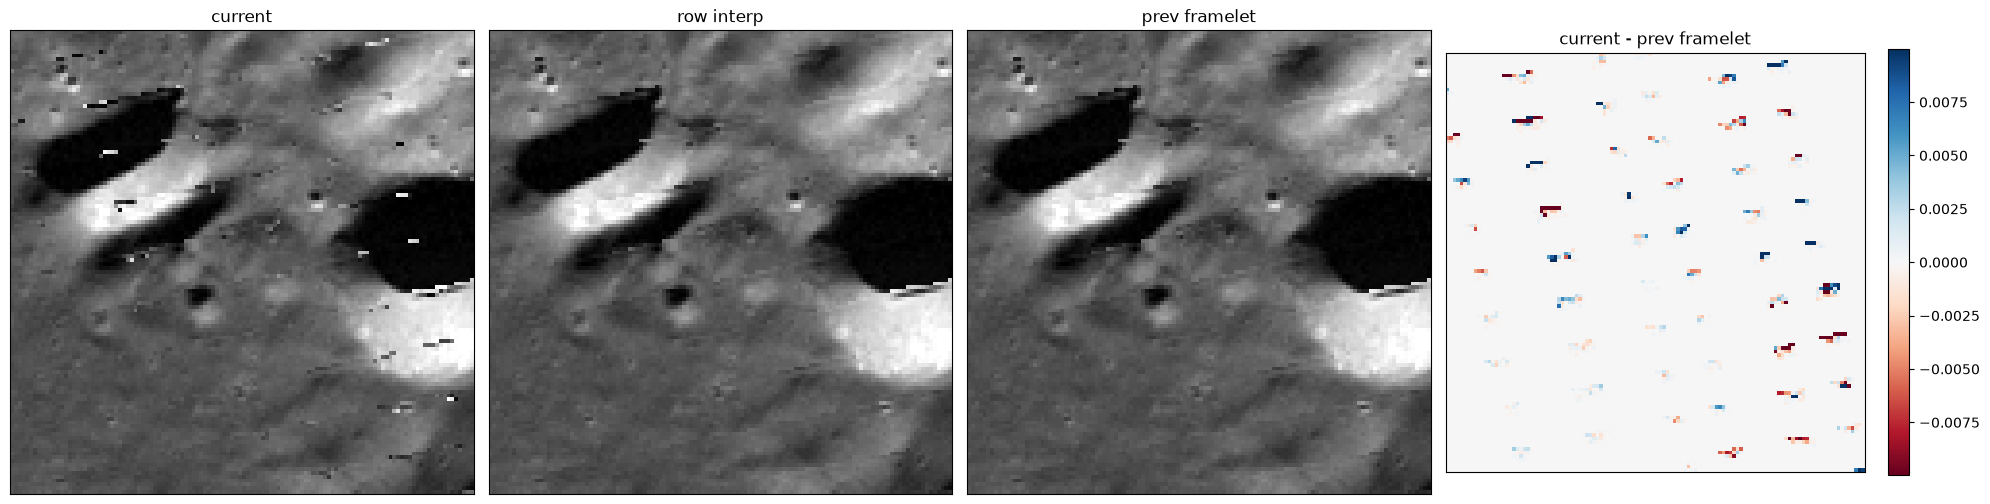

In [9]:
fills = {
    "row interp": fill_row_interp(band, boundary_nulls),
    "prev framelet": fill_from_previous_framelet(band, boundary_nulls, overlap),
}
variant_config = dataclasses.replace(entry.per_image_config, output_dir=work_dir)
textures = {"current": plotting.read_raster_band(isis_wac.run_cam2map_for_crop(crop, dem, variant_config))}
texture_paths = {}
for name, filled in fills.items():
    cub = write_filled_cube(crop.cub_path, work_dir / f"{PRODUCT_ID}_crop_{name.replace(' ', '_')}.cub", filled)
    texture_paths[name] = isis_wac.run_cam2map_for_crop(isis_wac.CropResult(cub_path=cub), dem, variant_config)
    textures[name] = plotting.read_raster_band(texture_paths[name])
textures = {k: np.where(plotting.valid_pixel_mask(v), v, np.nan) for k, v in textures.items()}

texture_window = busiest_window(textures["current"] - textures["prev framelet"])
_ = show_zooms(textures, texture_window, diff_of=("current", "prev framelet"))

## Effect on the `reproject` render

The same textures through `render.run_sat_sim` with `entry.camera`, the step `reproject` itself
runs. "current" is this dataset's own `reproject` output.

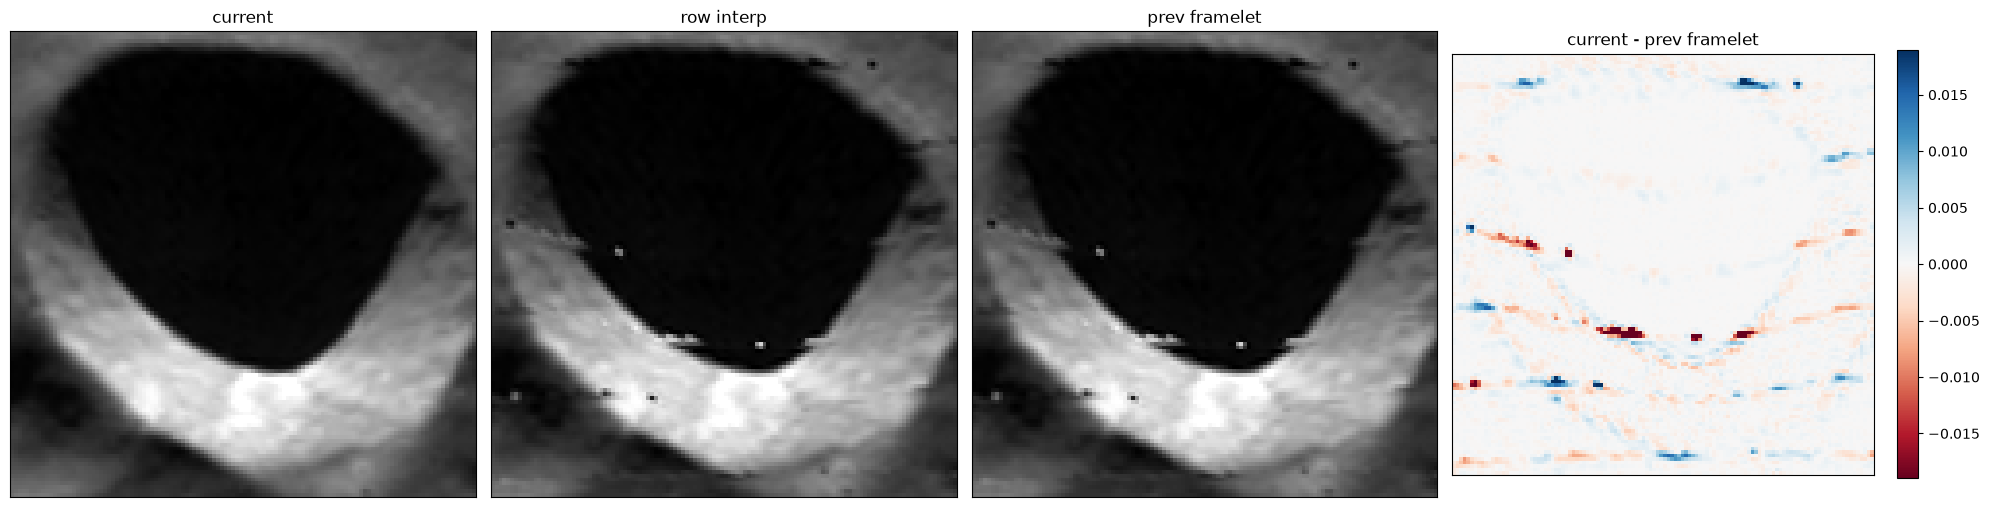

In [10]:
renders = {"current": plotting.read_raster_band(baseline_render)}
for name, tif in texture_paths.items():
    render_config = dataclasses.replace(variant_config, output_dir=work_dir / name.replace(" ", "_"))
    result = render.run_sat_sim(entry.camera, dem_ortho.result_from_files(tif, dem.dem), render_config)
    renders[name] = plotting.read_raster_band(result.rendered_tif)
renders = {k: np.where(plotting.valid_pixel_mask(v), v.astype(np.float32), np.nan) for k, v in renders.items()}

render_diff = renders["current"] - renders["prev framelet"]
render_window = busiest_window(render_diff)
_ = show_zooms(renders, render_window, diff_of=("current", "prev framelet"))

render px changed by more than 1% of the median: 910416 of 1731856


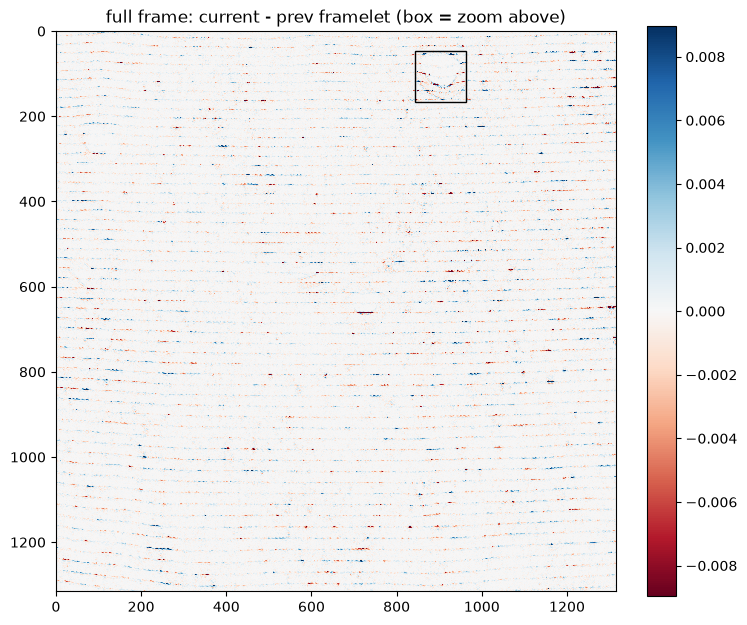

In [11]:
fig, ax = plt.subplots(figsize=(8, 8))
lim = np.nanpercentile(np.abs(render_diff), 99.9)
im = ax.imshow(render_diff, cmap="RdBu", vmin=-lim, vmax=lim, interpolation="none")
ax.add_patch(plt.Rectangle((render_window[1].start, render_window[0].start), ZOOM, ZOOM, fill=False, ec="k"))
fig.colorbar(im, ax=ax, fraction=0.046)
_ = ax.set_title("full frame: current - prev framelet (box = zoom above)")
changed = np.abs(render_diff) > 0.01 * np.nanmedian(renders["current"])
print(f"render px changed by more than 1% of the median: {changed.sum()} of {np.isfinite(render_diff).sum()}")

## What's left: framelet seams

Some short dashes survive both fills. They sit on the framelet seams: the lines drawn from phase 13
(each framelet's last line) show up as a dashed line in the map, interleaved with the next
framelet's first lines, and a crater-shadow edge steps by a pixel there. The camera-model check
above shows adjacent framelets agree on geometry to a few hundredths of a line, so this is not
misregistration between framelets. The next section shows it's `cam2map` placing those phase-13
pixels in the wrong place.

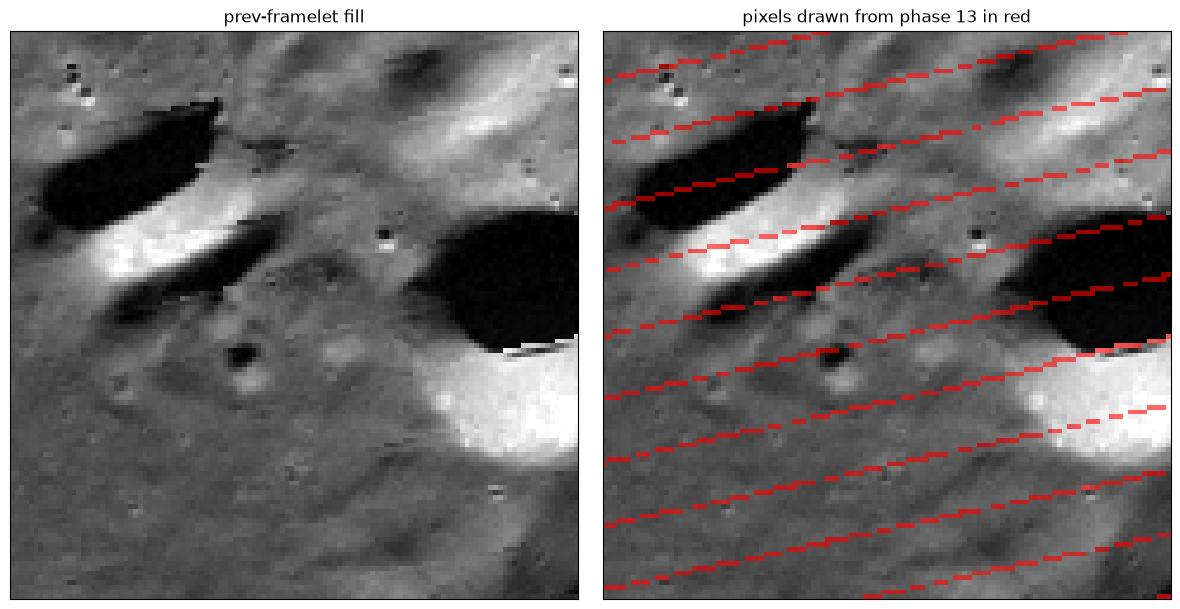

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
texture = textures["prev framelet"][texture_window]
vmin, vmax = stretch(texture)
axes[0].imshow(texture, cmap="gray", vmin=vmin, vmax=vmax, interpolation="none")
axes[0].set_title("prev-framelet fill")
axes[1].imshow(texture, cmap="gray", vmin=vmin, vmax=vmax, interpolation="none")
axes[1].imshow(
    np.where(source_phase[texture_window] == VIS_BLOCK_HEIGHT - 1, 1.0, np.nan),
    cmap="autumn",
    alpha=0.6,
    interpolation="none",
)
axes[1].set_title("pixels drawn from phase 13 in red")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
fig.tight_layout()

## A `cam2map` replacement: map-to-image resampling

`wac_resample.resample_crop` works backwards from the map, one output pixel at a time:

1. Ground point from the map pixel's position and the height of ISIS's lunar shape model (the same
   model `spiceinit` attached to the crop, which `cam2map` intersects too).
2. Project it into the crop's framelets with `pose_alignment.wac_camera_model`'s optics chain,
   vectorized. Where two framelets see it, take the one that puts it closer to its own center line:
   a single seam in the middle of each overlap.
3. Sample that framelet alone, by cubic convolution. If any interpolation tap is NULL, use the other
   overlapping framelet instead, so the framelet-boundary NULLs need no fill. Where no framelet has
   all 16 cubic taps valid, fall back to bilinear; where none has all four bilinear taps valid
   either (next to the detector's dead edge columns, or at the crop's ends), average the valid
   taps, as long as the pixel containing the point is itself valid.
4. `fill_small_holes` closes any enclosed hole of up to 4 px from its neighbors. Across the four
   entries in this notebook that is a single pixel, a notch at the swath edge.

Here it writes to the same map grid `cam2map` produced, so the two compare pixel for pixel. (In the
pipeline, `wac_resample.resample_crop_to_map` writes to the DEM's own pixel grid instead.)

In [13]:
grid = MapGrid.from_raster(texture_paths["prev framelet"])
resampled = resample_crop(crop.cub_path, band, grid, config)
resampled_values, hole_filled = fill_small_holes(resampled.value)
resampled_tif = write_geotiff(resampled_values, grid, work_dir / f"{PRODUCT_ID}_resampled.tif", float(ISIS_NULL))
textures["resampler"] = resampled_values
current_valid, resampler_valid = np.isfinite(textures["current"]), np.isfinite(resampled_values)
print(
    f"valid px: cam2map {current_valid.sum()}, resampler {resampler_valid.sum()} "
    f"(only cam2map {(current_valid & ~resampler_valid).sum()}, only resampler {(resampler_valid & ~current_valid).sum()}, "
    f"holes filled {hole_filled.sum()})"
)

valid px: cam2map 751348, resampler 751180 (only cam2map 170, only resampler 2, holes filled 0)


### Where each map pixel's value comes from, checked against ISIS's own camera

For a random sample of map pixels, take the crop pixel each method drew from, send it to ground with
`campt`, and measure how far that ground point lands from the map pixel's own center. Nearest-
neighbor rounding alone allows up to about 0.7 px. `cam2map`'s pixels are grouped by which framelet
line they came from.

In [14]:
def map_position_error(crop_cub, map_grid, samples, lines, rows, cols, n=60, seed=0):
    """`campt` round trip: distance, in map px, from each map pixel to where its source crop pixel
    (ISIS 1-based sample/line) actually images."""
    pick = np.random.default_rng(seed).choice(len(rows), min(n, len(rows)), replace=False)
    pixels = np.stack([samples[pick], lines[pick]], axis=1)
    to_map = Transformer.from_crs(geographic_crs(), map_grid.crs, always_xy=True)
    errors = []
    for row, col, ground in zip(
        rows[pick], cols[pick], isis_campt.image_to_ground_points_batch(crop_cub, pixels), strict=True
    ):
        if ground is not None:
            x, y = to_map.transform(ground[0], ground[1])
            map_col, map_row = ~map_grid.transform * (x, y)
            errors.append(np.hypot(map_col - (col + 0.5), map_row - (row + 0.5)))
    return pd.Series(errors).describe(percentiles=[0.5, 0.9])[["count", "50%", "90%", "max"]]


source_phase_valid = np.isfinite(source_lines)
groups = {
    "cam2map, from phase 13": source_phase_valid & (source_phase == VIS_BLOCK_HEIGHT - 1),
    "cam2map, from phase 0": source_phase_valid & (source_phase == 0),
    "cam2map, from phases 3-9": source_phase_valid
    & (source_phase >= INTERIOR_PHASES[0])
    & (source_phase <= INTERIOR_PHASES[1]),
}
position_errors = {}
for label, mask in groups.items():
    rows_g, cols_g = np.nonzero(mask)
    position_errors[label] = map_position_error(
        crop.cub_path, grid, source_samples[rows_g, cols_g] + 1, source_lines[rows_g, cols_g] + 1, rows_g, cols_g
    )
rows_r, cols_r = np.nonzero(np.isfinite(resampled.line))
position_errors["resampler (no rounding)"] = map_position_error(
    crop.cub_path, grid, resampled.sample[rows_r, cols_r], resampled.line[rows_r, cols_r], rows_r, cols_r
)
print(f"cam2map px drawn from phase 13: {groups['cam2map, from phase 13'].sum()} of {source_phase_valid.sum()}")
pd.DataFrame(position_errors).T.round(2)

cam2map px drawn from phase 13: 49578 of 755703


,count,50%,90%,max
"cam2map, from phase 13",60.0,2.80,4.43,5.07
"cam2map, from phase 0",60.0,0.48,0.71,0.95
"cam2map, from phases 3-9",60.0,0.50,0.71,0.93
resampler (no rounding),60.0,0.00,0.01,0.03


`cam2map` places pixels from every framelet line correctly except the last one. Its phase-13 pixels
land about 3 map pixels (roughly 300 m) from where ISIS's own camera says they image. These are the
dashed lines in the seam figure above. The resampler's choices land where `campt` puts them.

The next figure shows which framelet line each map pixel came from, for both methods, over the top
40 rows of the zoom. `cam2map`'s
seams are ragged: phase 13 shows through as dashes. The resampler's are single clean lines in
the middle of each overlap, moved only where it steered around a NULL.

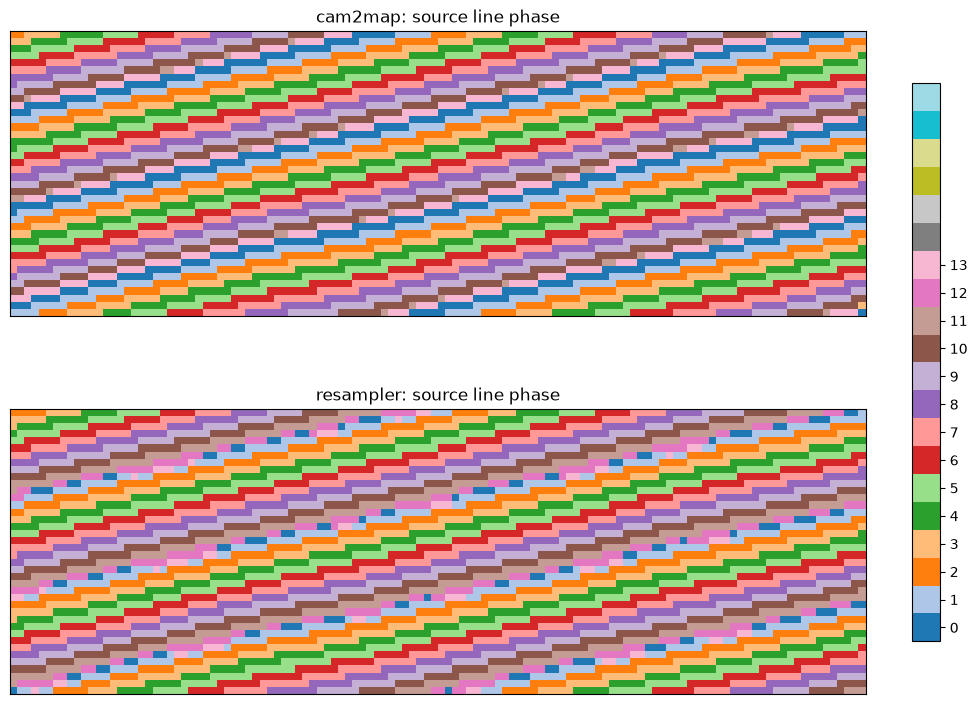

In [15]:
seam_window = (slice(texture_window[0].start, texture_window[0].start + 40), texture_window[1])  # top of the zoom
resampled_phase = np.where(np.isfinite(resampled.line), np.floor(resampled.line - 1) % VIS_BLOCK_HEIGHT, np.nan)
fig, axes = plt.subplots(2, 1, figsize=(12, 9))
for ax, phase, title in (
    (axes[0], np.where(source_phase >= 0, source_phase, np.nan), "cam2map"),
    (axes[1], resampled_phase, "resampler"),
):
    im = ax.imshow(phase[seam_window], cmap="tab20", vmin=-0.5, vmax=19.5, interpolation="none")
    ax.set_title(f"{title}: source line phase")
    ax.set_xticks([])
    ax.set_yticks([])
fig.colorbar(im, ax=axes, ticks=range(VIS_BLOCK_HEIGHT), fraction=0.03)

### Texture and render

The same zoom as before, now with the resampler's texture, and that texture rendered through
`render.run_sat_sim` like the others.

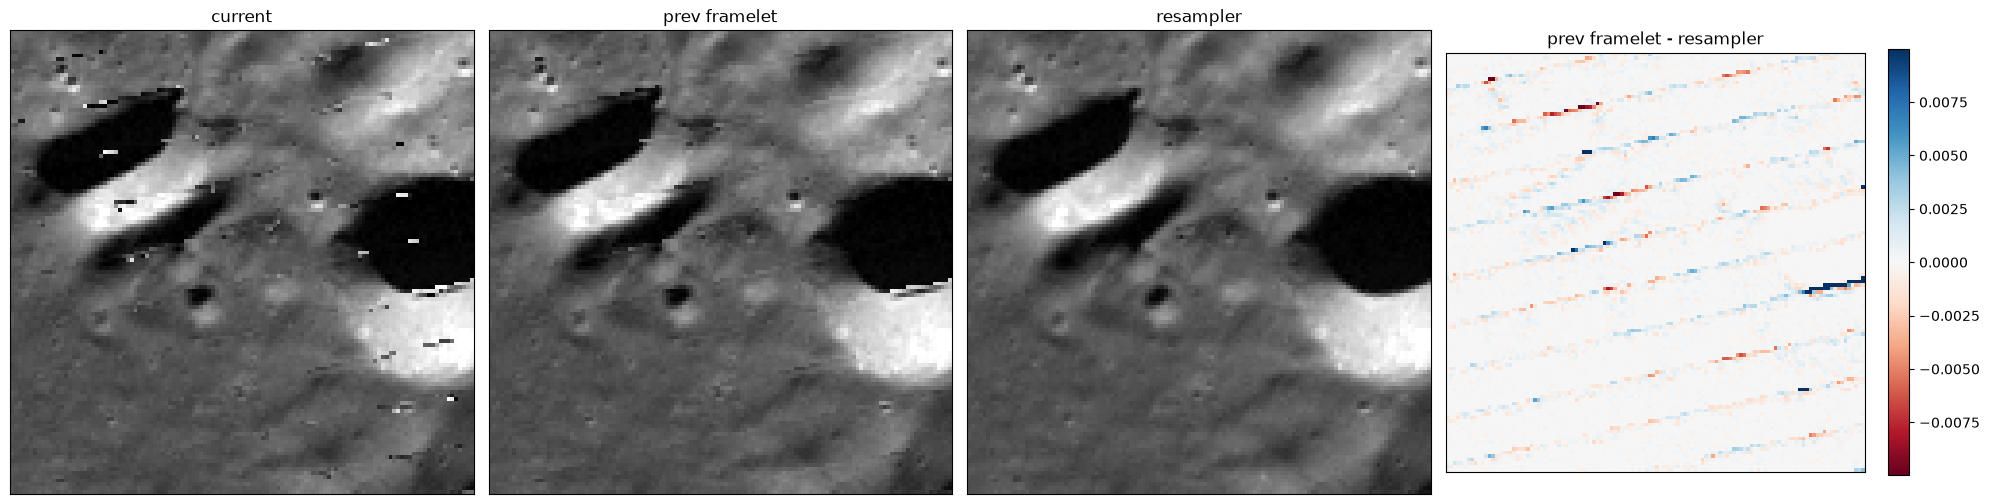

In [16]:
_ = show_zooms(
    {k: textures[k] for k in ("current", "prev framelet", "resampler")},
    texture_window,
    diff_of=("prev framelet", "resampler"),
)

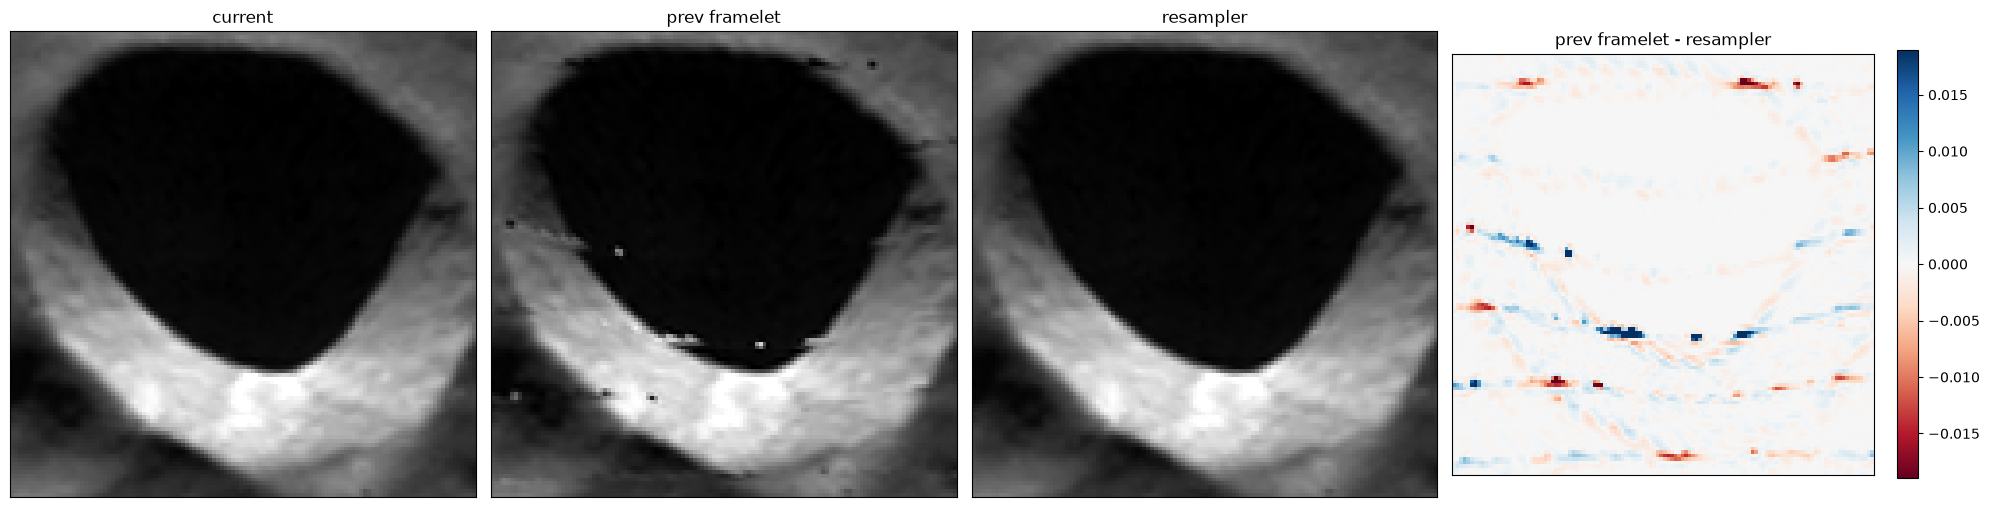

In [17]:
render_config = dataclasses.replace(variant_config, output_dir=work_dir / "resampler")
result = render.run_sat_sim(entry.camera, dem_ortho.result_from_files(resampled_tif, dem.dem), render_config)
renders["resampler"] = plotting.read_raster_band(result.rendered_tif).astype(np.float32)
renders["resampler"] = np.where(plotting.valid_pixel_mask(renders["resampler"]), renders["resampler"], np.nan)
_ = show_zooms(
    {k: renders[k] for k in ("current", "prev framelet", "resampler")},
    render_window,
    diff_of=("prev framelet", "resampler"),
)

### Sharpness

`cam2map`'s texture has more fine detail than the resampler's, but most of that difference is at the
framelet seams, where it comes from `cam2map`'s own seam errors. Split the map into pixels drawn from
the middle of a framelet (phases 3-9, by both methods) and pixels next to a seam, and compare the
high-pass energy (difference from a 1 px Gaussian blur) of the donor-filled `cam2map` texture and
the resampler's in each. In the interiors the resampler keeps about 90% of `cam2map`'s: both use
cubic convolution, but `cam2map`'s kernel measures as the sharper a = -1 variant, which boosts high
frequencies and is off by about 2% of a pixel step even on a plane. The resampler uses a = -0.5, the
variant that reproduces planes and quadratics exactly.

In [18]:
resampled_phase_int = np.where(np.isfinite(resampled.line), np.floor(resampled.line - 1) % VIS_BLOCK_HEIGHT, -1)
both_valid = binary_erosion(
    np.isfinite(textures["prev framelet"]) & np.isfinite(textures["resampler"]), np.ones((9, 9))
)
interior = binary_erosion(
    (source_phase >= INTERIOR_PHASES[0])
    & (source_phase <= INTERIOR_PHASES[1])
    & (resampled_phase_int >= INTERIOR_PHASES[0])
    & (resampled_phase_int <= INTERIOR_PHASES[1]),
    np.ones((7, 7)),
)
zones = {"framelet interior": both_valid & interior, "near a seam": both_valid & ~interior}
sharpness = {}
for zone, mask in zones.items():
    row = {"pixels": int(mask.sum())}
    for name in ("prev framelet", "resampler"):
        high_pass = textures[name] - gaussian_filter(np.nan_to_num(textures[name]), 1.0)
        row[f"{name} high-pass RMS"] = np.sqrt(np.mean(high_pass[mask] ** 2))
    row["resampler / cam2map"] = row["resampler high-pass RMS"] / row["prev framelet high-pass RMS"]
    sharpness[zone] = row
pd.DataFrame(sharpness).T.rename(columns=lambda c: c.replace("prev framelet", "cam2map (donor-filled)"))

,pixels,cam2map (donor-filled) high-pass RMS,resampler high-pass RMS,resampler / cam2map
framelet interior,21546.0,0.000870,0.000781,0.897583
near a seam,713063.0,0.001102,0.000851,0.772733


### Alignment against the basemap

An independent check that the resampler doesn't shift anything: phase-correlate 128 px tiles of each
texture against the relit WAC_EMP ortho `hillshade` renders from. A shift that grew toward the swath
edges would point at a geometry error in one method.

,cam2map row,cam2map col,resampler row,resampler col
mean,0.38,0.57,0.32,0.61
max,0.86,0.96,0.87,0.92


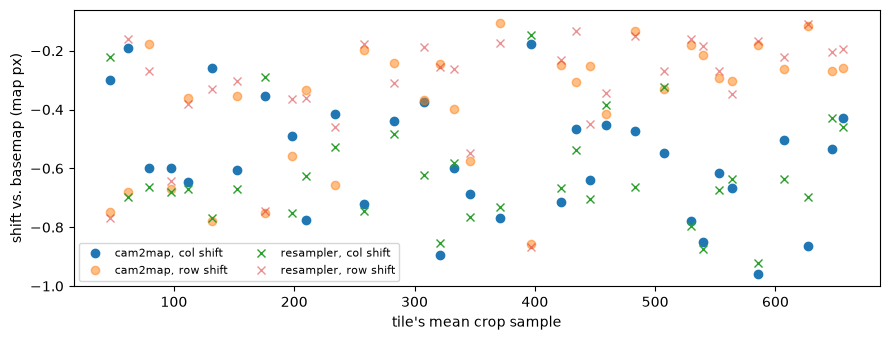

In [19]:
def tile_offset(moving: np.ndarray, reference: np.ndarray) -> tuple[float, float]:
    """(row, col) shift of `moving` relative to `reference`, by FFT phase correlation with a
    parabolic sub-pixel peak."""
    window = np.outer(np.hanning(moving.shape[0]), np.hanning(moving.shape[1]))
    a = np.nan_to_num(moving - np.nanmean(moving)) * window
    b = np.nan_to_num(reference - np.nanmean(reference)) * window
    cross = np.fft.fft2(a) * np.conj(np.fft.fft2(b))
    corr = np.fft.fftshift(np.real(np.fft.ifft2(cross / (np.abs(cross) + 1e-12))))
    i, j = np.unravel_index(np.argmax(corr), corr.shape)

    def refine(minus, peak, plus):
        denominator = minus - 2 * peak + plus
        return 0.5 * (minus - plus) / denominator if denominator else 0.0

    di = refine(corr[i - 1, j], corr[i, j], corr[i + 1, j])
    dj = refine(corr[i, j - 1], corr[i, j], corr[i, j + 1])
    return i + di - moving.shape[0] // 2, j + dj - moving.shape[1] // 2


basemap = np.full(grid.shape, np.nan)
with rasterio.open(dem.ortho) as src:
    rasterio.warp.reproject(
        rasterio.band(src, 1),
        basemap,
        dst_transform=grid.transform,
        dst_crs=grid.crs,
        dst_nodata=np.nan,
        resampling=rasterio.warp.Resampling.bilinear,
    )
TILE = 128
tiles = []
for row0 in range(0, grid.shape[0] - TILE, TILE):
    for col0 in range(0, grid.shape[1] - TILE, TILE):
        tile = (slice(row0, row0 + TILE), slice(col0, col0 + TILE))
        images = {"cam2map": textures["current"][tile], "resampler": resampled.value[tile], "basemap": basemap[tile]}
        if min(np.isfinite(v).mean() for v in images.values()) < MIN_TILE_COVERAGE:
            continue
        entry_row = {"crop sample": np.nanmean(resampled.sample[tile])}
        for name in ("cam2map", "resampler"):
            d_row, d_col = tile_offset(images[name], images["basemap"])
            entry_row[f"{name} row"], entry_row[f"{name} col"] = d_row, d_col
        tiles.append(entry_row)
tiles = pd.DataFrame(tiles).sort_values("crop sample")
fig, ax = plt.subplots(figsize=(9, 3.5))
for name, marker in (("cam2map", "o"), ("resampler", "x")):
    ax.plot(tiles["crop sample"], tiles[f"{name} col"], marker, label=f"{name}, col shift")
    ax.plot(tiles["crop sample"], tiles[f"{name} row"], marker, alpha=0.5, label=f"{name}, row shift")
ax.set_xlabel("tile's mean crop sample")
ax.set_ylabel("shift vs. basemap (map px)")
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
tiles.drop(columns="crop sample").abs().describe().loc[["mean", "max"]].round(2)

## Other entries

The same checks on three more entries: `M1309273576CE` (`trntest2`, 34 deg S, April 2019),
`M1314403930CE` (`trntest1`, 55 deg N) and `M1327210646CE` (38 deg N, November 2019). The last is
the opposite yaw state (`reverse_crop_along_track`), which reverses the framelet order in the crop.
Each row reports:

- the framelet-boundary NULL pattern;
- image-fit vs. camera-model overlap;
- the `campt` round-trip map-position error for `cam2map`'s phase-13 pixels, its other pixels, and
  the resampler;
- both textures' alignment against the basemap;
- run times, coverage, and interior holes (NaN pixels enclosed by valid ones) before
  `fill_small_holes`.

In [20]:
def basemap_on(map_grid: MapGrid, dem_ortho_result) -> np.ndarray:
    """`dem_ortho_result`'s relit WAC_EMP ortho, bilinearly resampled onto `map_grid`."""
    out = np.full(map_grid.shape, np.nan)
    with rasterio.open(dem_ortho_result.ortho) as src:
        rasterio.warp.reproject(
            rasterio.band(src, 1),
            out,
            dst_transform=map_grid.transform,
            dst_crs=map_grid.crs,
            dst_nodata=np.nan,
            resampling=rasterio.warp.Resampling.bilinear,
        )
    return out


def mean_basemap_offset(texture: np.ndarray, reference: np.ndarray, others: list[np.ndarray]) -> tuple[float, float]:
    """Mean |row|, |col| `tile_offset` of `texture` against `reference`, over tiles every image in
    `others` also covers."""
    offsets = []
    for row0 in range(0, texture.shape[0] - TILE, TILE):
        for col0 in range(0, texture.shape[1] - TILE, TILE):
            tile = (slice(row0, row0 + TILE), slice(col0, col0 + TILE))
            if min(np.isfinite(v[tile]).mean() for v in [texture, reference, *others]) >= MIN_TILE_COVERAGE:
                offsets.append(tile_offset(texture[tile], reference[tile]))
    return tuple(np.abs(np.array(offsets)).mean(axis=0))


def interior_holes(values: np.ndarray) -> int:
    valid = np.isfinite(values)
    return int((binary_fill_holes(valid) & ~valid).sum())


summary, zooms = [], {}
for product_id in OTHER_ENTRIES:
    other = dataset[product_id]
    other_crop, other_dem = other.crop_result, other.dem_ortho_result
    other_band = read_all_bands(other_crop.cub_path)[0]
    other_config = dataclasses.replace(other.per_image_config, output_dir=work_dir / product_id)
    nulls = framelet_boundary_nulls(other_band)

    start = time.perf_counter()
    other_tif = isis_wac.run_cam2map_for_crop(other_crop, other_dem, other_config)
    cam2map_s = time.perf_counter() - start
    other_grid = MapGrid.from_raster(other_tif)
    other_current = plotting.read_raster_band(other_tif)
    other_current = np.where(plotting.valid_pixel_mask(other_current), other_current, np.nan)
    start = time.perf_counter()
    other_resampled = resample_crop(other_crop.cub_path, other_band, other_grid, config)
    resampler_s = time.perf_counter() - start
    other_values, other_filled = fill_small_holes(other_resampled.value)

    fit = fit_framelet_overlap(other_band)
    _, points = camera_model_overlap(other_crop.cub_path)
    by_column = points.groupby("column")[["line_offset", "sample_shift"]].mean()

    trace_lines, trace_samples = cam2map_source_pixels(
        other_crop.cub_path, other_dem, work_dir / f"{product_id}_source.tif"
    )
    trace_phase = np.where(np.isfinite(trace_lines), np.nan_to_num(trace_lines).astype(int) % VIS_BLOCK_HEIGHT, -1)
    errors = {}
    for label, mask in (
        ("cam2map phase 13", trace_phase == VIS_BLOCK_HEIGHT - 1),
        ("cam2map phases 3-9", (trace_phase >= INTERIOR_PHASES[0]) & (trace_phase <= INTERIOR_PHASES[1])),
    ):
        rows_m, cols_m = np.nonzero(mask)
        errors[label] = map_position_error(
            other_crop.cub_path,
            other_grid,
            trace_samples[rows_m, cols_m] + 1,
            trace_lines[rows_m, cols_m] + 1,
            rows_m,
            cols_m,
            n=40,
        )["50%"]
    rows_m, cols_m = np.nonzero(np.isfinite(other_resampled.line))
    errors["resampler"] = map_position_error(
        other_crop.cub_path,
        other_grid,
        other_resampled.sample[rows_m, cols_m],
        other_resampled.line[rows_m, cols_m],
        rows_m,
        cols_m,
        n=40,
    )["max"]

    reference = basemap_on(other_grid, other_dem)
    both = [other_current, other_resampled.value]
    summary.append(
        {
            "entry": product_id,
            "reversed": other.camera.reverse_crop_along_track,
            "NULL cols / phases": f"{nulls[::VIS_BLOCK_HEIGHT].any(axis=0).sum()} / {sorted({int(p) for p in np.nonzero(nulls)[0] % VIS_BLOCK_HEIGHT})}",
            "overlap |model - fit| line": np.mean(np.abs(by_column["line_offset"] - fit.line_offset[by_column.index])),
            "overlap |model - fit| shift": np.mean(
                np.abs(by_column["sample_shift"] - fit.sample_shift[by_column.index])
            ),
            "campt err, cam2map phase 13 (median px)": errors["cam2map phase 13"],
            "campt err, cam2map phases 3-9 (median px)": errors["cam2map phases 3-9"],
            "campt err, resampler (max px)": errors["resampler"],
            "basemap |offset| cam2map (row, col)": np.round(mean_basemap_offset(other_current, reference, both), 2),
            "basemap |offset| resampler (row, col)": np.round(
                mean_basemap_offset(other_resampled.value, reference, both), 2
            ),
            "cam2map s": round(cam2map_s, 1),
            "resampler s": round(resampler_s, 1),
            "valid px cam2map / resampler": f"{np.isfinite(other_current).sum()} / {np.isfinite(other_values).sum()}",
            "interior holes cam2map / resampler (before fill)": f"{interior_holes(other_current)} / {interior_holes(other_resampled.value)}",
            "holes filled": int(other_filled.sum()),
        }
    )
    zooms[product_id] = (other_current, other_values, busiest_window(other_current - other_resampled.value))
pd.DataFrame(summary).set_index("entry").round(3).T

ROI center (lon,lat deg): (np.float64(-143.61227043364002), np.float64(-33.643245408897)), bbox (local m): (-73168.71432826061, -70630.35315334657, 70917.02773753201, 71559.76797118684)
ROI size 1441x1422 px (~100.0 m/px)


WAC_EMP tile(s): WAC_EMP_643NM_E300S2250_304P


ROI center (lon,lat deg): (np.float64(143.83515473394), np.float64(55.103088928903006)), bbox (local m): (-98392.57828433513, -99221.23412876412, 97332.17523585394, 102777.48939631703)
ROI size 1957x2020 px (~100.0 m/px)


WAC_EMP tile(s): WAC_EMP_643NM_E300N1350_304P


ROI center (lon,lat deg): (np.float64(169.57626968656), np.float64(38.772057415183994)), bbox (local m): (-119430.90633989371, -120503.30209323166, 119303.62237253919, 123544.69999758614)
ROI size 2387x2440 px (~100.0 m/px)


WAC_EMP tile(s): WAC_EMP_643NM_E300N1350_304P


entry,M1309273576CE,M1314403930CE,M1327210646CE
reversed,False,False,True
NULL cols / phases,53 / [0],53 / [0],53 / [0]
overlap |model - fit| line,0.046,0.047,0.06
overlap |model - fit| shift,0.053,0.056,0.042
"campt err, cam2map phase 13 (median px)",4.155,4.178,4.915
"campt err, cam2map phases 3-9 (median px)",0.5,0.662,0.788
"campt err, resampler (max px)",0.027,0.012,0.03
"basemap |offset| cam2map (row, col)","[0.2, 0.5]","[0.15, 0.13]","[0.61, 0.15]"
"basemap |offset| resampler (row, col)","[0.19, 0.47]","[0.16, 0.12]","[0.57, 0.18]"
cam2map s,20.9,21.5,24.8


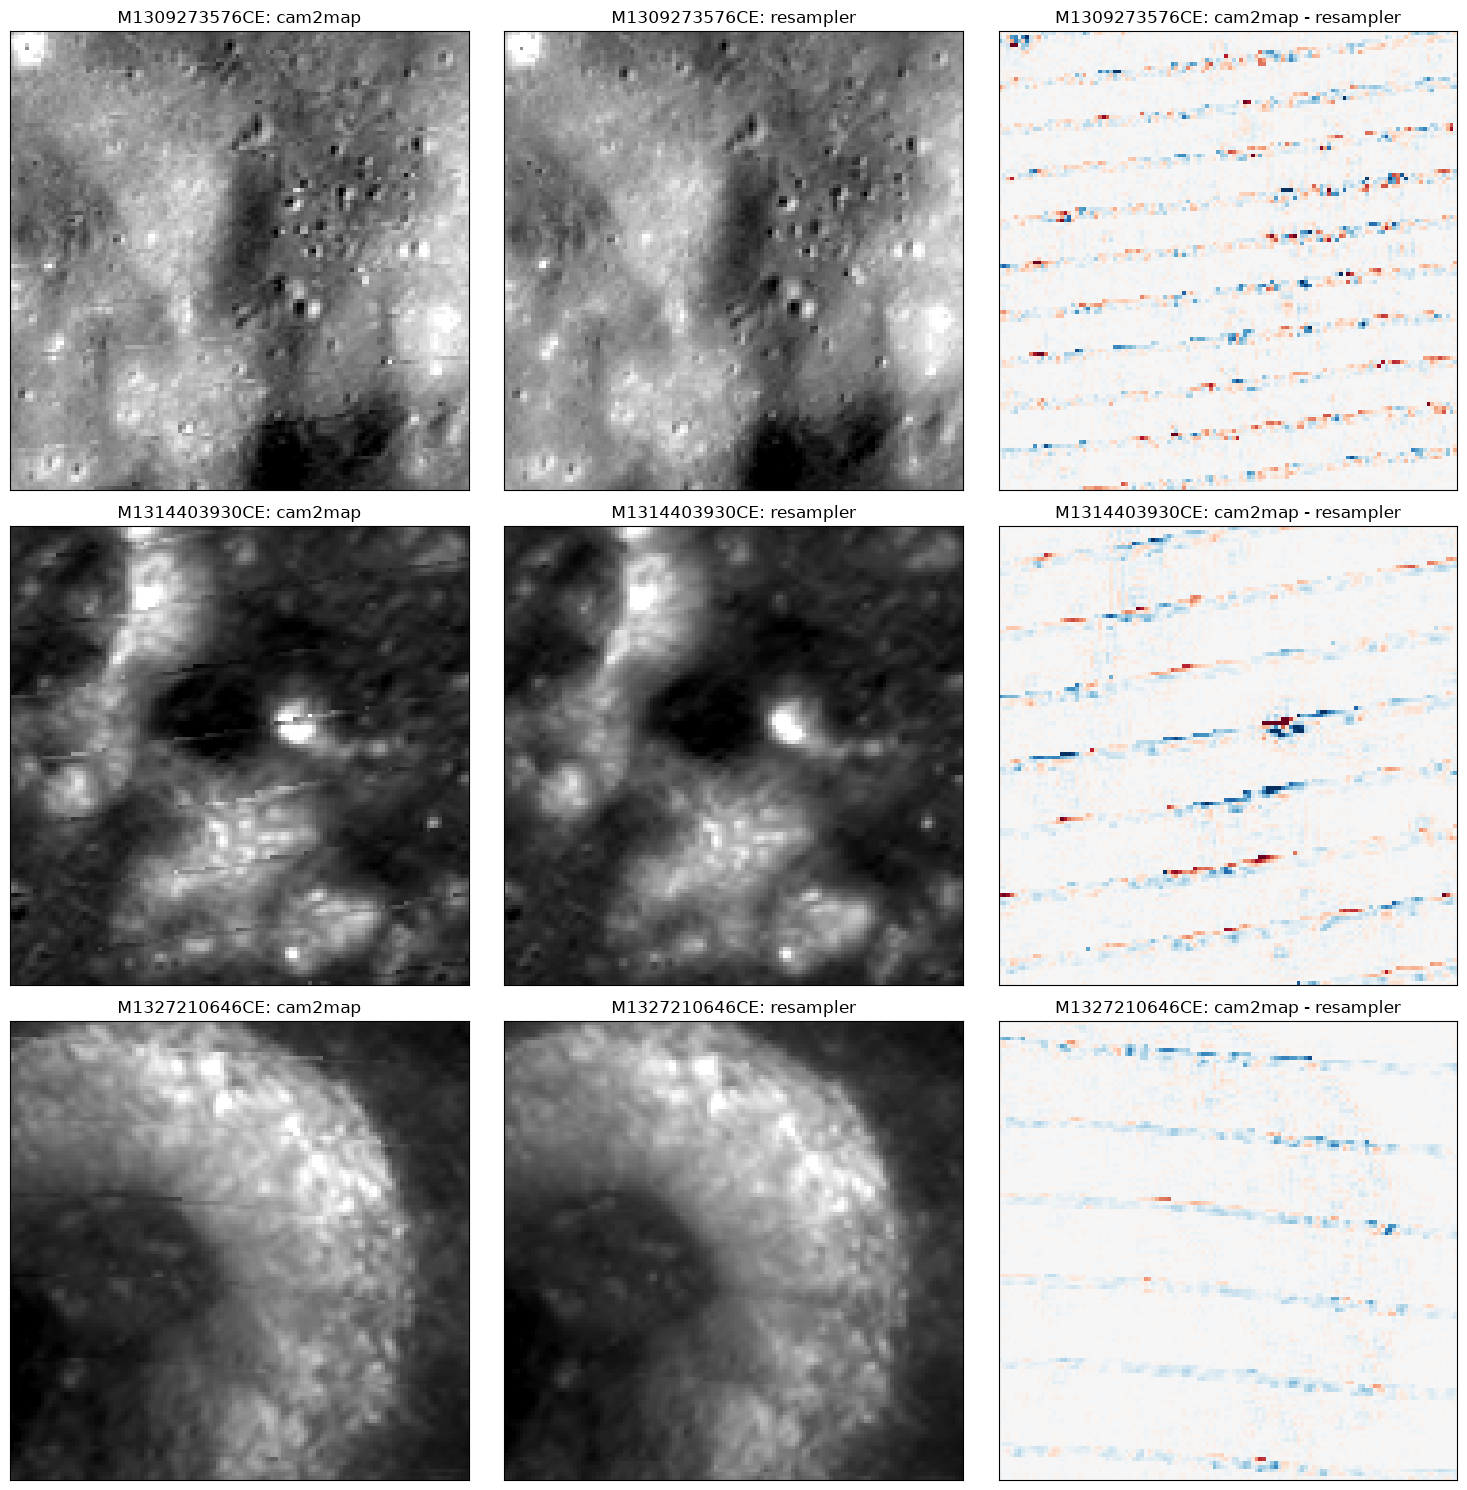

In [21]:
fig, axes = plt.subplots(len(zooms), 3, figsize=(15, 5 * len(zooms)))
for ax_row, (product_id, (current_texture, resampled_texture, window)) in zip(axes, zooms.items(), strict=True):
    vmin, vmax = stretch(current_texture[window])
    lim = (vmax - vmin) / 4
    ax_row[0].imshow(current_texture[window], cmap="gray", vmin=vmin, vmax=vmax, interpolation="none")
    ax_row[1].imshow(resampled_texture[window], cmap="gray", vmin=vmin, vmax=vmax, interpolation="none")
    ax_row[2].imshow(
        (current_texture - resampled_texture)[window], cmap="RdBu", vmin=-lim, vmax=lim, interpolation="none"
    )
    for ax, title in zip(ax_row, ("cam2map", "resampler", "cam2map - resampler"), strict=True):
        ax.set_title(f"{product_id}: {title}")
        ax.set_xticks([])
        ax.set_yticks([])
fig.tight_layout()

## Findings

- The NULLs are one line at one edge of the framelet: phase 0, the same 53 columns in every
  framelet, in band 1 (the other bands have 1-2 extra NULLs there).
- `cam2map` keeps that line over the previous framelet's overlapping lines, so filling it in the
  crop, before `cam2map`, removes the dashes and specks it causes.
- The previous-framelet donor, with a fitted per-column offset, roughly halves the held-out error
  of row interpolation. An integer "two lines back" donor is no better than interpolation.
- The camera model predicts the same overlap as the image fit: mean differences of 0.03 lines and
  0.06 px, within the fit's own grid spacing. A fill using the camera-model overlap does as well
  as one using the image fit, so the image fit isn't needed wherever SPICE is available.
- The overlap should vary with each image's interframe delay and ground speed, so compute it per
  crop rather than hardcoding this one's.
- The fill has to happen after `framestitch`: before it, a framelet's neighbors are in the other
  even/odd cube. `lrowaccal` refuses a cropped cube, but a pixel edit on the crop is fine.
- Framelet-seam dashes remain after either fill. They are `cam2map` misplacing each framelet's
  last line by about 3 map pixels (confirmed with `campt`); every other line lands correctly.
- `wac_resample.resample_crop` avoids both problems by construction: one seam in the middle of each
  overlap, steered around NULLs, interpolation within one framelet. Its pixels land where `campt`
  says they image, it matches `cam2map`'s alignment to the basemap, and it runs faster.
- All of this holds on the three other entries, including the opposite yaw state: the same 53-column
  phase-0 NULL pattern, image and camera-model overlap agreeing to ~0.05 lines, and `cam2map`'s
  phase-13 pixels misplaced by 3-5 map px.
- The resampler's coverage matches `cam2map`'s to within 0.02% on all four entries, differing only
  by a pixel or so at the swath edges. No interior NULL survives except one swath-edge notch, which
  `fill_small_holes` closes.
- Inside framelets the resampler's texture keeps about 90% of `cam2map`'s fine detail. Both use cubic
  convolution, but `cam2map`'s measures as the a = -1 variant, sharper-looking and less accurate than
  the resampler's a = -0.5. Next to seams, `cam2map`'s extra detail is its own seam error.
- Unlike `cam2map`, the resampler depends on `wac_camera_model` and SPICE, and takes framelet poses
  from the SPICE kernels rather than the cube's own SPICE tables, so a crop whose tables were edited
  still needs `cam2map`.